# SPY + Options Extension (No Full Retraining)

This notebook extends the Table 2 replication toward **real market data** using:
- historical **SPY** prices,
- listed **SPY options chain**,
- and the already-saved baseline from `results_table2/table2_summary.json`.

Default mode is **no full retraining**: we only build a real-data benchmark and evaluate hedging-error MSE. Optional quick fine-tuning is provided at the end.

In [ ]:
import os, sys, json, math
from urllib.request import urlopen, Request
from urllib.error import HTTPError, URLError
from datetime import datetime, timezone

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

try:
    import yfinance as yf
except Exception:
    yf = None

ROOT = os.path.abspath(os.path.join(os.getcwd(), '..'))
if ROOT not in sys.path:
    sys.path.insert(0, ROOT)

from src.experiment import report_table, Config, run_experiment
from src.architectures import ClassicalLSTM, AugmentedLSTM
from src.payoffs import call_payoff
from src.simulators import compute_norm_stats

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
np.random.seed(42)
torch.manual_seed(42)
print('Device:', DEVICE)
print('yfinance available:', yf is not None)

Device: cpu
yfinance available: True


c:\Users\Michael\Code\ML-for-Finance\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1) Load saved Table 2 baseline (no retrain)

In [2]:
summary_path = os.path.join(ROOT, 'results_table2', 'table2_summary.json')
with open(summary_path, 'r', encoding='utf-8') as f:
    table2 = json.load(f)

print('Loaded:', summary_path)
for exp, rows in table2['results'].items():
    for model, vals in rows.items():
        print(f"{exp:18s} | {model:16s} | our_mse={vals['our_mse']:.3e} | paper={vals['paper_mse']:.3e}")

Loaded: c:\Users\Michael\Code\ML-for-Finance\results_table2\table2_summary.json
BS call            | Classical LSTM   | our_mse=5.495e-05 | paper=5.730e-05
BS call            | Augmented LSTM   | our_mse=4.617e-05 | paper=3.970e-05
2-markets spread   | Classical LSTM   | our_mse=8.168e-05 | paper=3.640e-04
2-markets spread   | Augmented LSTM   | our_mse=8.419e-05 | paper=1.110e-04


## 2) Download real SPY prices + option chain snapshot

- SPY daily prices: Stooq CSV endpoint.
- SPY options snapshot: Yahoo Finance public options endpoint.

In [3]:
def fetch_text(url: str) -> str:
    req = Request(url, headers={'User-Agent': 'Mozilla/5.0'})
    return urlopen(req, timeout=25).read().decode('utf-8', errors='replace')


def fetch_yahoo_json(url: str):
    txt = fetch_text(url)
    return json.loads(txt)


def fetch_spy_close_yfinance():
    if yf is None:
        raise RuntimeError('yfinance is not installed.')
    h = yf.Ticker('SPY').history(period='max', interval='1d', auto_adjust=False)
    if h is None or h.empty or 'Close' not in h.columns:
        raise RuntimeError('yfinance returned empty SPY history.')
    close = h['Close'].to_numpy(dtype=float)
    dates = h.index.strftime('%Y-%m-%d').to_numpy()
    m = np.isfinite(close)
    close = close[m]
    dates = dates[m]
    if close.size < 200:
        raise RuntimeError(f'yfinance returned too few valid rows: {close.size}.')
    return dates, close


def fetch_spy_options_snapshot_yfinance():
    if yf is None:
        raise RuntimeError('yfinance is not installed.')
    tk = yf.Ticker('SPY')
    exps = list(tk.options)
    if not exps:
        raise RuntimeError('yfinance returned no SPY expiries.')

    now = datetime.now(timezone.utc)
    chosen = exps[0]
    for e in exps:
        dt = datetime.fromisoformat(e).replace(tzinfo=timezone.utc)
        if (dt - now).days >= 14:
            chosen = e
            break

    chain = tk.option_chain(chosen)
    calls_df = chain.calls.copy()
    puts_df = chain.puts.copy()

    # spot fallback sequence for robustness across yfinance versions
    spot = None
    for getter in (
        lambda: float(tk.fast_info.get('lastPrice')), 
        lambda: float(tk.history(period='1d', interval='1d', auto_adjust=False)['Close'].iloc[-1]),
    ):
        try:
            spot = getter()
            if np.isfinite(spot):
                break
        except Exception:
            pass
    if spot is None or not np.isfinite(spot):
        raise RuntimeError('Could not obtain SPY spot from yfinance.')

    expiry_dt = datetime.fromisoformat(chosen).replace(tzinfo=timezone.utc)
    expiry_epoch = int(expiry_dt.timestamp())

    calls = calls_df[['strike', 'bid', 'ask']].to_dict(orient='records')
    puts = puts_df[['strike', 'bid', 'ask']].to_dict(orient='records')

    return {
        'quote': {'regularMarketPrice': spot},
        'options': [{'expirationDate': expiry_epoch, 'calls': calls, 'puts': puts}],
    }


def fetch_spy_close_stooq():
    # No-auth fallback for price history.
    url = 'https://stooq.com/q/d/l/?s=spy.us&i=d'
    txt = fetch_text(url)
    lines = [ln.strip() for ln in txt.splitlines() if ln.strip()]
    if not lines or not lines[0].lower().startswith('date,open,high,low,close,volume'):
        raise RuntimeError('Stooq did not return expected CSV header.')

    dates, close = [], []
    for ln in lines[1:]:
        parts = ln.split(',')
        if len(parts) < 5:
            continue
        try:
            c = float(parts[4])
        except ValueError:
            continue
        if np.isfinite(c):
            dates.append(parts[0])
            close.append(c)

    close = np.asarray(close, dtype=float)
    dates = np.asarray(dates)
    if close.size < 200:
        raise RuntimeError(f'Stooq returned too few rows: {close.size}.')

    if close[0] > close[-1] and np.nanmean(np.diff(close[: min(120, close.size)])) < 0:
        dates = dates[::-1]
        close = close[::-1]
    return dates, close


def fetch_spy_close_yahoo_chart():
    url = 'https://query2.finance.yahoo.com/v8/finance/chart/SPY?range=max&interval=1d&events=history'
    data = fetch_yahoo_json(url)
    result = data['chart']['result'][0]
    ts = result.get('timestamp', [])
    closes = result['indicators']['quote'][0].get('close', [])

    pairs = [(t, c) for t, c in zip(ts, closes) if c is not None and np.isfinite(c)]
    if len(pairs) < 200:
        raise RuntimeError(f'Yahoo chart returned too few rows: {len(pairs)}.')

    dates = np.array([datetime.fromtimestamp(t, tz=timezone.utc).strftime('%Y-%m-%d') for t, _ in pairs])
    close = np.array([float(c) for _, c in pairs], dtype=float)
    return dates, close


def fetch_spy_options_snapshot_api():
    base = 'https://query2.finance.yahoo.com/v7/finance/options/SPY'
    root = fetch_yahoo_json(base)
    q = root['optionChain']['result'][0]
    exps = q.get('expirationDates', [])
    if not exps:
        raise RuntimeError('Yahoo options endpoint returned no expiries.')
    now = int(datetime.now(timezone.utc).timestamp())
    chosen = exps[0]
    for e in exps:
        if e - now >= 14 * 24 * 3600:
            chosen = e
            break
    snap = fetch_yahoo_json(f'{base}?date={chosen}')
    return snap['optionChain']['result'][0]


def fetch_spy_market_data():
    errors = []

    # 1) Best path: yfinance for both prices and options.
    try:
        dates, close = fetch_spy_close_yfinance()
        opt = fetch_spy_options_snapshot_yfinance()
        print('Data source: yfinance')
        return dates, close, opt
    except Exception as e:
        errors.append(f'yfinance path failed: {e}')

    # 2) No-auth price fallback (Stooq) + Yahoo options API.
    try:
        dates, close = fetch_spy_close_stooq()
        opt = fetch_spy_options_snapshot_api()
        print('Data source: Stooq (prices) + Yahoo options API')
        return dates, close, opt
    except Exception as e:
        errors.append(f'Stooq+Yahoo path failed: {e}')

    # 3) Yahoo chart + Yahoo options API.
    try:
        dates, close = fetch_spy_close_yahoo_chart()
        opt = fetch_spy_options_snapshot_api()
        print('Data source: Yahoo public APIs')
        return dates, close, opt
    except Exception as e:
        errors.append(f'Yahoo API path failed: {e}')

    msg = 'All market-data paths failed.\n' + '\n'.join(f' - {x}' for x in errors)
    msg += '\nInstall yfinance with: uv sync --extra notebook'
    raise RuntimeError(msg)


dates, close, opt = fetch_spy_market_data()
spot = float(opt['quote']['regularMarketPrice'])
expiry_epoch = int(opt['options'][0]['expirationDate'])
expiry_dt = datetime.fromtimestamp(expiry_epoch, tz=timezone.utc)

calls = opt['options'][0]['calls']
puts = opt['options'][0]['puts']
print(f'SPY history rows: {close.size}')
print(f'Current spot: {spot:.2f}')
print(f'Chosen expiry: {expiry_dt.date()} | calls={len(calls)} puts={len(puts)}')

Data source: yfinance
SPY history rows: 8361
Current spot: 710.60
Chosen expiry: 2026-05-08 | calls=122 puts=139


## 3) Build an ATM implied-vol proxy from listed options

In [4]:
def norm_cdf(x):
    return 0.5 * (1.0 + math.erf(x / math.sqrt(2.0)))

def bs_call_price(S, K, T, r, sigma):
    if T <= 0 or sigma <= 0:
        return max(S - K, 0.0)
    d1 = (math.log(S / K) + (r + 0.5 * sigma * sigma) * T) / (sigma * math.sqrt(T))
    d2 = d1 - sigma * math.sqrt(T)
    return S * norm_cdf(d1) - K * math.exp(-r * T) * norm_cdf(d2)

def implied_vol_call(mid, S, K, T, r=0.0):
    lo, hi = 1e-4, 5.0
    for _ in range(100):
        m = 0.5 * (lo + hi)
        p = bs_call_price(S, K, T, r, m)
        if p > mid:
            hi = m
        else:
            lo = m
    return 0.5 * (lo + hi)

valid_calls = [c for c in calls if c.get('bid') is not None and c.get('ask') is not None and c.get('strike') is not None]
if not valid_calls:
    raise RuntimeError('No valid call quotes found.')

atm_call = min(valid_calls, key=lambda c: abs(float(c['strike']) - spot))
K_atm = float(atm_call['strike'])
bid = float(atm_call['bid'])
ask = float(atm_call['ask'])
mid = 0.5 * (bid + ask)
T_years = max((expiry_epoch - int(datetime.now(timezone.utc).timestamp())) / (365.0 * 24 * 3600), 1/365)
iv_atm = implied_vol_call(mid=mid, S=spot, K=K_atm, T=T_years, r=0.0)

print(f'ATM strike: {K_atm:.2f}  bid/ask/mid: {bid:.3f}/{ask:.3f}/{mid:.3f}')
print(f'TTM (years): {T_years:.4f}')
print(f'Implied vol proxy (ATM): {iv_atm:.4f}')

ATM strike: 710.00  bid/ask/mid: 11.170/11.260/11.215
TTM (years): 0.0555
Implied vol proxy (ATM): 0.1635


## 4) Real-data extension metric (no training)

Construct SPY paths by moving-block bootstrap of daily log-returns.
For each path, hedge ATM call under fixed-IV Black-Scholes and compute terminal error:
`Y = pnl_hedge - payoff`, then report MSE.

In [5]:
def bootstrap_lr_paths(log_returns, n_paths=20000, n_steps=21, block_len=5, seed=7):
    rng = np.random.default_rng(seed)
    n_blocks = int(np.ceil(n_steps / block_len))
    max_start = log_returns.size - block_len
    if max_start < 0:
        raise ValueError('Not enough returns for block bootstrap.')
    out = np.empty((n_paths, n_steps + 1), dtype=np.float64)
    out[:, 0] = spot
    for i in range(n_paths):
        starts = rng.integers(0, max_start + 1, size=n_blocks)
        r = np.concatenate([log_returns[s:s+block_len] for s in starts])[:n_steps]
        out[i, 1:] = spot * np.exp(np.cumsum(r))
    return out

def bs_delta(S, K, T, r, sigma):
    if T <= 0 or sigma <= 0:
        return np.where(S > K, 1.0, 0.0)
    d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    return 0.5 * (1.0 + np.vectorize(math.erf)(d1 / np.sqrt(2.0)))

lr = np.diff(np.log(close))
lr = lr[np.isfinite(lr)]
paths = bootstrap_lr_paths(lr, n_paths=20000, n_steps=21, block_len=5, seed=17)

n_steps = paths.shape[1] - 1
dt = T_years / n_steps
p0 = bs_call_price(spot, K_atm, T_years, 0.0, iv_atm)
S0 = paths[:, 0]
delta_prev = bs_delta(S0, K_atm, T_years, 0.0, iv_atm)
cash = np.full(paths.shape[0], p0) - delta_prev * S0

for t in range(1, n_steps + 1):
    tau = max(T_years - t * dt, 0.0)
    St = paths[:, t]
    d_new = bs_delta(St, K_atm, tau, 0.0, iv_atm) if t < n_steps else np.zeros_like(St)
    cash -= (d_new - delta_prev) * St
    delta_prev = d_new

payoff = np.maximum(paths[:, -1] - K_atm, 0.0)
portfolio_T = cash + delta_prev * paths[:, -1]
Y = portfolio_T - payoff
mse_real = float(np.mean(Y**2))

print(f'Real SPY/options extension MSE: {mse_real:.3e}')
print(f'Y std: {np.std(Y):.3e}, mean: {np.mean(Y):.3e}')

Real SPY/options extension MSE: 7.503e+01
Y std: 7.882e+00, mean: -3.592e+00


In [6]:
mock_cfg = type('Cfg', (), {'paper_values': {}})()
ext_result = {
    'cfg': mock_cfg,
    'mse': {
        'BS delta hedge (real SPY/options)': mse_real,
    }
}

baseline = table2['results']['BS call']
print('\nSaved Table 2 baseline (BS call):')
for name, vals in baseline.items():
    print(f"  {name:16s}  {vals['our_mse']:.3e}")

print('\nExtension result:')
report_table({'SPY/options extension': ext_result}, title='SPY + OPTIONS (NO RETRAIN)')


Saved Table 2 baseline (BS call):
  Classical LSTM    5.495e-05
  Augmented LSTM    4.617e-05

Extension result:
  SPY + OPTIONS (NO RETRAIN)
  Experiment              Model                        Our MSE     Paper MSE       Ratio
--------------------------------------------------------------------------------------
  SPY/options extension   BS delta hedge (real SPY/options)     7.503e+01             —           —


In [7]:
# Paper-style incompleteness extension: proportional transaction costs.
# We compute MSE(Y) for different cost levels (in bps per notional traded).

def hedge_error_with_tc(paths, K, T, sigma, tc_bps):
    n_steps = paths.shape[1] - 1
    dt = T / n_steps
    p0 = bs_call_price(spot, K, T, 0.0, sigma)
    S0 = paths[:, 0]
    d_prev = bs_delta(S0, K, T, 0.0, sigma)
    cash = np.full(paths.shape[0], p0) - d_prev * S0
    tc_paid = np.zeros(paths.shape[0])

    for t in range(1, n_steps + 1):
        tau = max(T - t * dt, 0.0)
        St = paths[:, t]
        d_new = bs_delta(St, K, tau, 0.0, sigma) if t < n_steps else np.zeros_like(St)
        trade = d_new - d_prev
        tc_paid += (tc_bps * 1e-4) * np.abs(trade) * St
        cash -= trade * St
        d_prev = d_new

    payoff = np.maximum(paths[:, -1] - K, 0.0)
    portfolio_T = cash + d_prev * paths[:, -1]
    Y_tc = portfolio_T - payoff - tc_paid
    return Y_tc

for bps in [0, 1, 5, 10]:
    y_tc = hedge_error_with_tc(paths, K_atm, T_years, iv_atm, tc_bps=bps)
    print(f'tc={bps:>2} bps | MSE={np.mean(y_tc**2):.3e} | mean={np.mean(y_tc):.3e} | std={np.std(y_tc):.3e}')

tc= 0 bps | MSE=7.503e+01 | mean=-3.592e+00 | std=7.882e+00
tc= 1 bps | MSE=7.641e+01 | mean=-3.740e+00 | std=7.901e+00
tc= 5 bps | MSE=8.239e+01 | mean=-4.330e+00 | std=7.978e+00
tc=10 bps | MSE=9.098e+01 | mean=-5.068e+00 | std=8.080e+00


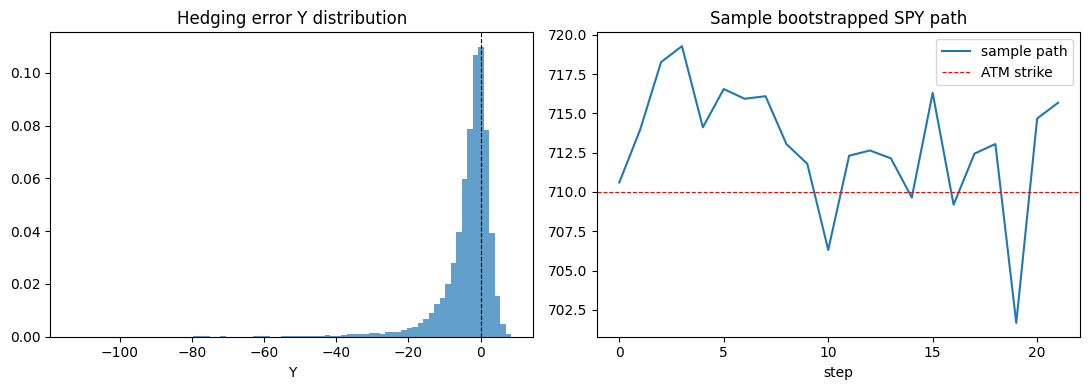

In [8]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].hist(Y, bins=80, density=True, alpha=0.7)
ax[0].axvline(0.0, color='k', ls='--', lw=0.8)
ax[0].set_title('Hedging error Y distribution')
ax[0].set_xlabel('Y')

ax[1].plot(paths[0, :], label='sample path')
ax[1].axhline(K_atm, color='r', ls='--', lw=0.8, label='ATM strike')
ax[1].set_title('Sample bootstrapped SPY path')
ax[1].set_xlabel('step')
ax[1].legend()

plt.tight_layout()
plt.show()

## 5) Table 2-style neural run on SPY (with BS benchmark + multi-seed)

This section mirrors the Table 2 workflow on SPY bootstrapped paths and adds:

- **Black-Scholes delta benchmark** row (from Section 4)
- **Multi-seed NN runs** for stability (mean/std across seeds)
- Side-by-side comparison of Classical vs Augmented LSTM against BS baseline

In [9]:
# Table 2-style NN experiment on SPY bootstrapped paths.
# This version includes a BS benchmark row and multi-seed statistics.

QUICK = False  # set True for smoke test, False for stronger run
SEEDS = [0, 1, 2]  # increase to [0,1,2,3,4] for final comparison
BLOCK_LEN = 5

if QUICK:
    N_ITER_SPY = 500
    N_TRAIN_SPY = 20_000
    N_EVAL_SPY = 10_000
    N_NORM_SPY = 10_000
else:
    N_ITER_SPY = 2_000
    N_TRAIN_SPY = 50_000
    N_EVAL_SPY = 20_000
    N_NORM_SPY = 20_000

BATCH_SIZE_SPY = 50
LR_SPY = 1e-3
LSTM_HIDDEN = 50
FF_WIDTH = 10
FF_LAYERS = 3
N_SPY = max(int(round(T_years * 365)), 5)


def make_spy_nn_paths(seed_base: int, block_len: int = BLOCK_LEN):
    # Build paths on spot scale for payoff realism, then shape to (batch, N+1, 1).
    lr = np.diff(np.log(close))
    lr = lr[np.isfinite(lr)]

    train = bootstrap_lr_paths(lr, n_paths=N_TRAIN_SPY, n_steps=N_SPY, block_len=block_len, seed=seed_base + 101)
    evl = bootstrap_lr_paths(lr, n_paths=N_EVAL_SPY, n_steps=N_SPY, block_len=block_len, seed=seed_base + 102)
    ref = bootstrap_lr_paths(lr, n_paths=N_NORM_SPY, n_steps=N_SPY, block_len=block_len, seed=seed_base + 999)

    train_t = torch.from_numpy(train.astype(np.float32)).unsqueeze(-1)
    evl_t = torch.from_numpy(evl.astype(np.float32)).unsqueeze(-1)
    ref_t = torch.from_numpy(ref.astype(np.float32)).unsqueeze(-1)

    mean, std = compute_norm_stats(ref_t)
    return train_t, evl_t, mean, std


seed_results = {}
for seed in SEEDS:
    np.random.seed(seed)
    torch.manual_seed(seed)

    cfg_spy_nn = Config(
        name=f'SPY call (Table2-style NN) / seed={seed}',
        d=1,
        N=N_SPY,
        paths_factory=lambda sb=seed: make_spy_nn_paths(sb),
        payoff_fn=lambda p: call_payoff(p[:, -1, 0], K=K_atm),
        arch_factory={
            'Classical LSTM': lambda: ClassicalLSTM(N=N_SPY, d=1, hidden=LSTM_HIDDEN),
            'Augmented LSTM': lambda: AugmentedLSTM(N=N_SPY, d=1, hidden=LSTM_HIDDEN, ff_width=FF_WIDTH, ff_layers=FF_LAYERS),
        },
        n_iter=N_ITER_SPY,
        batch_size=BATCH_SIZE_SPY,
        lr=LR_SPY,
        paper_values={},
    )

    print(f'\n=== seed={seed} | N={N_SPY}, iter={N_ITER_SPY}, train/eval/norm={N_TRAIN_SPY}/{N_EVAL_SPY}/{N_NORM_SPY} ===')
    seed_results[seed] = run_experiment(cfg_spy_nn, device=DEVICE)

# Aggregate NN stats across seeds
model_names = ['Classical LSTM', 'Augmented LSTM']
agg = {}
for model_name in model_names:
    vals = np.array([seed_results[s]['mse'][model_name] for s in SEEDS], dtype=float)
    agg[model_name] = {
        'mean': float(vals.mean()),
        'std': float(vals.std(ddof=1) if vals.size > 1 else 0.0),
        'per_seed': vals.tolist(),
    }

# Build comparable table that includes the BS benchmark from section 4.
mock_cfg = type('Cfg', (), {'paper_values': {}})()
cmp_results = {
    'SPY benchmark + NN': {
        'cfg': mock_cfg,
        'mse': {
            'BS delta hedge': float(mse_real),
            'Classical LSTM (mean over seeds)': agg['Classical LSTM']['mean'],
            'Augmented LSTM (mean over seeds)': agg['Augmented LSTM']['mean'],
        },
    }
}

report_table(cmp_results, title='SPY TABLE2-STYLE: BS BENCHMARK VS MULTI-SEED NN')

print('\nPer-seed NN MSE:')
for model_name in model_names:
    print(f"  {model_name}: mean={agg[model_name]['mean']:.3e}, std={agg[model_name]['std']:.3e}, values={[f'{v:.3e}' for v in agg[model_name]['per_seed']]}")

# Optional: save summary for reuse
spy_out = {
    'meta': {
        'quick': QUICK,
        'seeds': SEEDS,
        'n_iter': N_ITER_SPY,
        'n_train': N_TRAIN_SPY,
        'n_eval': N_EVAL_SPY,
        'n_norm': N_NORM_SPY,
        'N_steps': N_SPY,
        'spot': float(spot),
        'K_atm': float(K_atm),
        'ttm_years': float(T_years),
        'iv_atm': float(iv_atm),
    },
    'bs_benchmark_mse': float(mse_real),
    'nn': agg,
}
os.makedirs(os.path.join(ROOT, 'results_spy'), exist_ok=True)
out_path = os.path.join(ROOT, 'results_spy', 'spy_table2_multiseed_summary.json')
with open(out_path, 'w', encoding='utf-8') as f:
    json.dump(spy_out, f, indent=2)
print('\nSaved:', out_path)


=== seed=0 | N=20, iter=2000, train/eval/norm=50000/20000/20000 ===


SPY call (Table2-style NN) / seed=0:Classical LSTM: 100%|██████████| 2000/2000 [00:39<00:00, 50.34it/s]
SPY call (Table2-style NN) / seed=0:Augmented LSTM: 100%|██████████| 2000/2000 [00:55<00:00, 35.95it/s]



=== seed=1 | N=20, iter=2000, train/eval/norm=50000/20000/20000 ===


SPY call (Table2-style NN) / seed=1:Classical LSTM: 100%|██████████| 2000/2000 [00:41<00:00, 47.76it/s]
SPY call (Table2-style NN) / seed=1:Augmented LSTM: 100%|██████████| 2000/2000 [01:04<00:00, 31.19it/s]



=== seed=2 | N=20, iter=2000, train/eval/norm=50000/20000/20000 ===


SPY call (Table2-style NN) / seed=2:Classical LSTM: 100%|██████████| 2000/2000 [00:41<00:00, 48.26it/s]
SPY call (Table2-style NN) / seed=2:Augmented LSTM:  60%|██████    | 1205/2000 [00:38<00:25, 30.89it/s]SPY call (Table2-style NN) / seed=2:Augmented LSTM:  66%|██████▌   | 1324/2000 [00:43<00:21, 30.83it/s]SPY call (Table2-style NN) / seed=2:Augmented LSTM: 100%|██████████| 2000/2000 [01:09<00:00, 28.76it/s]


  SPY TABLE2-STYLE: BS BENCHMARK VS MULTI-SEED NN
  Experiment              Model                        Our MSE     Paper MSE       Ratio
--------------------------------------------------------------------------------------
  SPY benchmark + NN      BS delta hedge             7.503e+01             —           —
  SPY benchmark + NN      Classical LSTM (mean over seeds)     2.205e+02             —           —
  SPY benchmark + NN      Augmented LSTM (mean over seeds)     2.203e+02             —           —

Per-seed NN MSE:
  Classical LSTM: mean=2.205e+02, std=2.890e+00, values=['2.171e+02', '2.223e+02', '2.219e+02']
  Augmented LSTM: mean=2.203e+02, std=7.623e-01, values=['2.208e+02', '2.194e+02', '2.208e+02']

Saved: c:\Users\Michael\Code\ML-for-Finance\results_spy\spy_table2_multiseed_summary.json


## 6) Real option-data calibration and out-of-window hedge test

This section uses **actual SPY option contract time series** (via `yfinance`) to build a one-step hedging dataset:

- sample at date `t`: `(S_t, C_t, K, tau_t)` and next-day `(S_{t+1}, C_{t+1})`
- target to hedge: `dC = C_{t+1} - C_t`
- hedge instrument: underlying move `dS = S_{t+1} - S_t`

We then:

1. split rows by date into train/test windows,
2. calibrate a **single BS volatility** on train prices,
3. calibrate **Classical LSTM** and **Augmented LSTM** on train hedge error,
4. compare all methods on test hedge MSE.

In [10]:
# -------- Real option-data train/test calibration --------
from dataclasses import dataclass


@dataclass
class RealOptCfg:
    max_expiries: int = 6
    max_contracts_per_expiry: int = 18
    hist_period: str = '3mo'
    min_rows_per_contract: int = 12
    train_frac: float = 0.7
    nn_iter: int = 1200
    batch_size: int = 128
    lr: float = 1e-3


cfg_real = RealOptCfg()


def bs_call_vec(S, K, T, sigma, r=0.0):
    S = np.asarray(S, dtype=float)
    K = np.asarray(K, dtype=float)
    T = np.asarray(T, dtype=float)
    sigma = float(sigma)

    T = np.maximum(T, 1e-6)
    sigma = max(sigma, 1e-6)
    d1 = (np.log(np.maximum(S, 1e-12) / np.maximum(K, 1e-12)) + (r + 0.5 * sigma * sigma) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    cdf = np.vectorize(lambda x: 0.5 * (1.0 + math.erf(x / np.sqrt(2.0))))
    return S * cdf(d1) - K * np.exp(-r * T) * cdf(d2)


def bs_delta_vec(S, K, T, sigma, r=0.0):
    S = np.asarray(S, dtype=float)
    K = np.asarray(K, dtype=float)
    T = np.asarray(T, dtype=float)
    T = np.maximum(T, 1e-6)
    sigma = max(float(sigma), 1e-6)
    d1 = (np.log(np.maximum(S, 1e-12) / np.maximum(K, 1e-12)) + (r + 0.5 * sigma * sigma) * T) / (sigma * np.sqrt(T))
    cdf = np.vectorize(lambda x: 0.5 * (1.0 + math.erf(x / np.sqrt(2.0))))
    return cdf(d1)


def build_real_option_panel(ticker='SPY', cfg=cfg_real):
    tk = yf.Ticker(ticker)
    spot_now = float(tk.history(period='1d', interval='1d', auto_adjust=False)['Close'].iloc[-1])

    # Underlying daily close history for joins.
    s_hist = tk.history(period='1y', interval='1d', auto_adjust=False)[['Close']].copy()
    s_hist = s_hist.rename(columns={'Close': 'S'})
    s_hist.index = pd.to_datetime(s_hist.index).tz_localize(None)

    rows = []
    expiries = list(tk.options)[: cfg.max_expiries]
    for exp in expiries:
        exp_dt = pd.Timestamp(exp)
        ch = tk.option_chain(exp).calls.copy()
        if ch.empty:
            continue

        ch = ch[(ch['bid'] > 0) & (ch['ask'] > 0) & (ch['strike'] > 0)]
        if ch.empty:
            continue

        # Prioritize liquid near-ATM contracts to reduce noisy tails.
        ch['mny_dist'] = np.abs(ch['strike'] / spot_now - 1.0)
        liq_col = 'openInterest' if 'openInterest' in ch.columns else 'volume'
        ch = ch.sort_values([liq_col, 'mny_dist'], ascending=[False, True]).head(cfg.max_contracts_per_expiry)

        for _, r in ch.iterrows():
            sym = r['contractSymbol']
            K = float(r['strike'])

            try:
                oh = yf.Ticker(sym).history(period=cfg.hist_period, interval='1d', auto_adjust=False)[['Close']].copy()
            except Exception:
                continue
            if oh is None or oh.empty:
                continue

            oh.index = pd.to_datetime(oh.index).tz_localize(None)
            oh = oh.rename(columns={'Close': 'C'})
            df = oh.join(s_hist, how='inner').dropna()
            if df.shape[0] < cfg.min_rows_per_contract:
                continue

            df = df.sort_index()
            df['S_next'] = df['S'].shift(-1)
            df['C_next'] = df['C'].shift(-1)
            df = df.dropna()
            if df.empty:
                continue

            df['dS'] = df['S_next'] - df['S']
            df['dC'] = df['C_next'] - df['C']
            # Time-to-expiry as seen on date t (in years).
            tau_days = (exp_dt - df.index).days.astype(float)
            df['tau'] = np.maximum(tau_days / 365.0, 1.0 / 365.0)
            df['K'] = K
            df['contract'] = sym
            df['expiry'] = exp
            df = df[df['tau'] > 0]
            rows.append(df[['S', 'S_next', 'C', 'C_next', 'dS', 'dC', 'tau', 'K', 'contract', 'expiry']])

    if not rows:
        raise RuntimeError('No option history rows were collected. Try increasing hist_period/max_expiries.')

    panel = pd.concat(rows).sort_index()
    panel = panel[np.isfinite(panel['S']) & np.isfinite(panel['C']) & np.isfinite(panel['dS']) & np.isfinite(panel['dC'])]
    panel = panel[(panel['S'] > 0) & (panel['C'] > 0) & (panel['K'] > 0)]
    return panel


def calibrate_bs_sigma(train_df):
    # Single-vol calibration minimizing train price MSE over a grid.
    sigmas = np.linspace(0.05, 1.00, 96)
    errs = []
    S = train_df['S'].to_numpy()
    K = train_df['K'].to_numpy()
    tau = train_df['tau'].to_numpy()
    C = train_df['C'].to_numpy()

    for s in sigmas:
        p = bs_call_vec(S, K, tau, s)
        errs.append(np.mean((p - C) ** 2))
    i = int(np.argmin(errs))
    return float(sigmas[i]), float(errs[i])


def fit_nn_delta_model(model, train_df, val_df=None, n_iter=1000, batch_size=128, lr=1e-3, seed=0):
    np.random.seed(seed)
    torch.manual_seed(seed)

    def to_tensors(df):
        # N=1 path: [S_t, S_{t+1}] for one traded asset.
        raw = np.stack([df['S'].to_numpy(), df['S_next'].to_numpy()], axis=1).astype(np.float32)
        raw_t = torch.from_numpy(raw).unsqueeze(-1)
        target = torch.from_numpy(df['dC'].to_numpy().astype(np.float32))
        return raw_t, target

    tr_raw, tr_dC = to_tensors(train_df)
    mean, std = compute_norm_stats(tr_raw)
    tr_norm = (tr_raw - mean) / std

    if val_df is not None and not val_df.empty:
        va_raw, va_dC = to_tensors(val_df)
        va_norm = (va_raw - mean) / std
    else:
        va_raw = va_dC = va_norm = None

    model = model.to(DEVICE)
    tr_raw = tr_raw.to(DEVICE)
    tr_norm = tr_norm.to(DEVICE)
    tr_dC = tr_dC.to(DEVICE)
    mean = mean.to(DEVICE)
    std = std.to(DEVICE)

    if va_raw is not None:
        va_raw = va_raw.to(DEVICE)
        va_norm = va_norm.to(DEVICE)
        va_dC = va_dC.to(DEVICE)

    opt = torch.optim.Adam(model.parameters(), lr=lr)

    n = tr_raw.shape[0]
    best = {'loss': float('inf'), 'state': None}
    for it in range(n_iter):
        idx = torch.randint(0, n, (min(batch_size, n),), device=DEVICE)
        br, bn, bd = tr_raw[idx], tr_norm[idx], tr_dC[idx]

        out = model(br, bn, liq=float('inf'), tc_cost=None)
        y = out['pnl'] - bd
        loss = (y ** 2).mean()

        opt.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        opt.step()

        if va_raw is not None and ((it + 1) % 100 == 0 or it == n_iter - 1):
            model.eval()
            with torch.no_grad():
                o = model(va_raw, va_norm, liq=float('inf'), tc_cost=None)
                val_loss = float(((o['pnl'] - va_dC) ** 2).mean().item())
            model.train()
            if val_loss < best['loss']:
                best['loss'] = val_loss
                best['state'] = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

    if best['state'] is not None:
        model.load_state_dict(best['state'])

    return model, mean, std


def eval_nn_delta_model(model, mean, std, df):
    raw = np.stack([df['S'].to_numpy(), df['S_next'].to_numpy()], axis=1).astype(np.float32)
    raw_t = torch.from_numpy(raw).unsqueeze(-1).to(DEVICE)
    norm_t = (raw_t - mean) / std
    dC_t = torch.from_numpy(df['dC'].to_numpy().astype(np.float32)).to(DEVICE)

    model.eval()
    with torch.no_grad():
        out = model(raw_t, norm_t, liq=float('inf'), tc_cost=None)
        resid = out['pnl'] - dC_t
        mse = float((resid ** 2).mean().item())
    return mse


# 1) Build panel and split by date window
panel = build_real_option_panel(cfg=cfg_real)
unique_dates = np.array(sorted(panel.index.unique()))
cut_idx = max(1, int(len(unique_dates) * cfg_real.train_frac))
cut_date = unique_dates[cut_idx - 1]

train_df = panel.loc[panel.index <= cut_date].copy()
test_df = panel.loc[panel.index > cut_date].copy()

# keep a small validation slice from tail of train
tr_dates = np.array(sorted(train_df.index.unique()))
val_start = tr_dates[max(1, int(len(tr_dates) * 0.85)) - 1]
val_df = train_df.loc[train_df.index >= val_start].copy()
train_core = train_df.loc[train_df.index < val_start].copy()
if train_core.empty:
    train_core = train_df.copy()

print(f'Rows total={len(panel):,}, train={len(train_core):,}, val={len(val_df):,}, test={len(test_df):,}')
print(f'Contracts total={panel.contract.nunique()}, train={train_core.contract.nunique()}, test={test_df.contract.nunique()}')
print(f'Date split at {pd.Timestamp(cut_date).date()}')

# 2) BS calibration on train window
sigma_star, bs_price_mse = calibrate_bs_sigma(train_core)
print(f'BS calibrated sigma={sigma_star:.4f}, train price MSE={bs_price_mse:.3e}')

# Hedging residual for BS on train/test
for tag, df_ in [('train', train_core), ('test', test_df)]:
    d_bs = bs_delta_vec(df_['S'].to_numpy(), df_['K'].to_numpy(), df_['tau'].to_numpy(), sigma_star)
    resid = df_['dC'].to_numpy() - d_bs * df_['dS'].to_numpy()
    print(f'BS hedge {tag} MSE={np.mean(resid**2):.3e}')

# 3) NN calibration (same family as paper table)
N_REAL = 1
classic = ClassicalLSTM(N=N_REAL, d=1, hidden=50)
augment = AugmentedLSTM(N=N_REAL, d=1, hidden=50, ff_width=10, ff_layers=3)

classic, c_mean, c_std = fit_nn_delta_model(
    classic, train_core, val_df=val_df, n_iter=cfg_real.nn_iter,
    batch_size=cfg_real.batch_size, lr=cfg_real.lr, seed=42,
)
augment, a_mean, a_std = fit_nn_delta_model(
    augment, train_core, val_df=val_df, n_iter=cfg_real.nn_iter,
    batch_size=cfg_real.batch_size, lr=cfg_real.lr, seed=42,
)

# 4) Evaluate all on held-out test window
bs_test_delta = bs_delta_vec(test_df['S'].to_numpy(), test_df['K'].to_numpy(), test_df['tau'].to_numpy(), sigma_star)
bs_test_mse = float(np.mean((test_df['dC'].to_numpy() - bs_test_delta * test_df['dS'].to_numpy()) ** 2))

classic_test_mse = eval_nn_delta_model(classic, c_mean, c_std, test_df)
augment_test_mse = eval_nn_delta_model(augment, a_mean, a_std, test_df)

print('\n=== OUT-OF-WINDOW (TEST) HEDGE MSE ===')
print(f'BS delta (calibrated): {bs_test_mse:.3e}')
print(f'Classical LSTM:        {classic_test_mse:.3e}')
print(f'Augmented LSTM:        {augment_test_mse:.3e}')

# 5) Compact table via report_table-compatible dict
mock_cfg = type('Cfg', (), {'paper_values': {}})()
comparison = {
    'Real options test window': {
        'cfg': mock_cfg,
        'mse': {
            'BS delta (calibrated)': bs_test_mse,
            'Classical LSTM': classic_test_mse,
            'Augmented LSTM': augment_test_mse,
        },
    }
}
report_table(comparison, title='REAL OPTION DATA: CALIBRATE ON TRAIN, HEDGE ON TEST')

NameError: name 'pd' is not defined